
## 1. Generate toy dataset


In [ ]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)

In [9]:


N = 50
x = torch.linspace(-3, 3, N).reshape(-1, 1)

true_w = torch.tensor([[2.0]])
true_b = torch.tensor([[1.0]])

noise = 1.0 * torch.randn(N, 1)
y = x @ true_w + true_b + noise


print("Closed-form solution")
print(f"w = {true_w.item():.4f}, b = {true_b.item():.4f}")



Closed-form solution
w = 2.0000, b = 1.0000


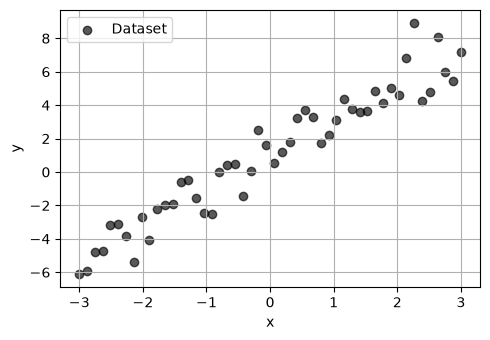

In [4]:
# ============================================================
# Plot dataset only
# ============================================================
plt.figure(figsize=(5, 3.5))

plt.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.65,
    label="Dataset"
)

plt.xlabel("x")
plt.ylabel("y")
# plt.title("Toy Dataset")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Closed-form solution


In [10]:

lam = 1e-3

# Augmented design matrix: [x, 1]
X_aug = torch.cat([x, torch.ones_like(x)], dim=1)  # shape: (N, 2)

# Regularization matrix
# We regularize w, but not bias b.
I = torch.eye(X_aug.shape[1])
I[-1, -1] = 0.0

# Since the training loss uses mean squared loss,
# the matching closed-form solution uses N * lam.
theta_closed = torch.linalg.solve(
    X_aug.T @ X_aug + N * lam * I,
    X_aug.T @ y
)

w_closed = theta_closed[0:1]   # shape: (1, 1)
b_closed = theta_closed[1:2]   # shape: (1, 1)


print("Closed-form solution")
print(f"w = {w_closed.item():.4f}, b = {b_closed.item():.4f}")




Closed-form solution
w = 2.0949, b = 1.0488


## 3. Gradient descent training


In [14]:
w = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, 1, requires_grad=True)

lr = 0.05
num_steps = 100
save_steps = [0, 1, 5, 10, 50, 99]

loss_history = []
snapshots = {}


def compute_loss(w, b):
    y_pred = x @ w + b
    mse_loss = 0.5 * torch.mean((y - y_pred) ** 2)
    reg_loss = 0.5 * lam * torch.sum(w ** 2)
    return mse_loss + reg_loss


for k in range(num_steps):
    # Compute loss
    loss = compute_loss(w, b)

    # Save loss and current parameter
    loss_history.append(loss.item())

    if k in save_steps:
        snapshots[k] = (w.detach().clone(), b.detach().clone())

    # Backpropagation
    loss.backward()
    

    print(f"Step {k}: loss = {loss.item():.4f}, w = {w.item():.4f}, b = {b.item():.4f}")  

    # Gradient descent update
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Reset gradients
    w.grad.zero_()
    b.grad.zero_()


w_gd = w.detach()
b_gd = b.detach()


print("\nGradient descent solution")
print(f"w = {w_gd.item():.4f}, b = {b_gd.item():.4f}")




Step 0: loss = 24.2474, w = -1.7703, b = 0.2143
Step 1: loss = 17.4949, w = -1.1667, b = 0.2560
Step 2: loss = 12.6803, w = -0.6573, b = 0.2956
Step 3: loss = 9.2463, w = -0.2275, b = 0.3333
Step 4: loss = 6.7959, w = 0.1352, b = 0.3691
Step 5: loss = 5.0463, w = 0.4413, b = 0.4031
Step 6: loss = 3.7962, w = 0.6995, b = 0.4354
Step 7: loss = 2.9022, w = 0.9175, b = 0.4660
Step 8: loss = 2.2622, w = 1.1013, b = 0.4952
Step 9: loss = 1.8033, w = 1.2565, b = 0.5228
Step 10: loss = 1.4737, w = 1.3874, b = 0.5491
Step 11: loss = 1.2364, w = 1.4979, b = 0.5741
Step 12: loss = 1.0652, w = 1.5912, b = 0.5979
Step 13: loss = 0.9411, w = 1.6698, b = 0.6204
Step 14: loss = 0.8509, w = 1.7362, b = 0.6418
Step 15: loss = 0.7850, w = 1.7922, b = 0.6622
Step 16: loss = 0.7365, w = 1.8395, b = 0.6815
Step 17: loss = 0.7006, w = 1.8794, b = 0.6999
Step 18: loss = 0.6738, w = 1.9131, b = 0.7173
Step 19: loss = 0.6535, w = 1.9415, b = 0.7339
Step 20: loss = 0.6381, w = 1.9654, b = 0.7496
Step 21: loss = 

## 4. comparison between the closed-form so`lution and the gradient descent solution

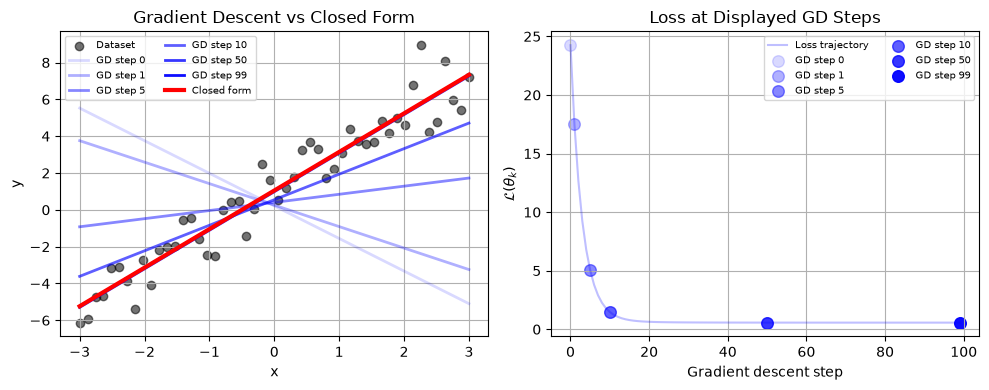

In [15]:
# ============================================================
# 4. Visualization
# ============================================================
x_plot = torch.linspace(-3, 3, 100).reshape(-1, 1)
y_closed = x_plot @ w_closed + b_closed

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

gd_steps = list(snapshots.keys())
alphas = torch.linspace(0.15, 0.95, len(gd_steps))


# ------------------------------------------------------------
# Left: GD trajectory and closed-form solution
# ------------------------------------------------------------
ax = axes[0]

ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.55,
    label="Dataset"
)

for alpha, k in zip(alphas, gd_steps):
    wk, bk = snapshots[k]
    y_gd_step = x_plot @ wk + bk

    ax.plot(
        x_plot.numpy(),
        y_gd_step.numpy(),
        color="blue",
        alpha=float(alpha),
        linewidth=2,
        label=f"GD step {k}"
    )

ax.plot(
    x_plot.numpy(),
    y_closed.numpy(),
    color="red",
    linewidth=3,
    label="Closed form"
)

ax.set_title("Gradient Descent vs Closed Form")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.legend(fontsize=7, ncol=2)


# ------------------------------------------------------------
# Right: Loss values corresponding to displayed GD steps
# ------------------------------------------------------------
ax = axes[1]

# Full loss trajectory
ax.plot(
    range(num_steps),
    loss_history,
    color="blue",
    alpha=0.25,
    linewidth=1.5,
    label="Loss trajectory"
)

# Loss values corresponding to the GD steps shown in the left panel
for alpha, k in zip(alphas, gd_steps):
    ax.scatter(
        k,
        loss_history[k],
        color="blue",
        alpha=float(alpha),
        s=70,
        label=f"GD step {k}"
    )

ax.set_title("Loss at Displayed GD Steps")
ax.set_xlabel("Gradient descent step")
ax.set_ylabel(r"$\mathcal{L}(\theta_k)$")
ax.grid(True)
ax.legend(fontsize=7, ncol=2)


# ============================================================
# 5. Save and show
# ============================================================
plt.tight_layout()
# fig.savefig("gd_vs_closed_form.png", dpi=300, bbox_inches="tight")
plt.show()